In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import cartopy
import os

In [2]:
metadata_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/metadata/40_50yr_sites.csv')
metadata_df.set_index('Number',inplace=True)

flow_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/flows/seasonal/50yrs/all_sites_all_seasons.csv')
flow_df.date = pd.to_datetime(flow_df.date)
flow_df.set_index('date', inplace=True)


In [3]:
subset_meta = metadata_df.loc[[int(s) for s in flow_df.columns]]

subset_meta.sort_values('gauge_lat', ascending = False, inplace=True)
subset_meta['number_label'] = np.arange(1,len(subset_meta)+1)
subset_meta['number_copy'] = subset_meta.index.values.tolist()

meta_df = gpd.GeoDataFrame(subset_meta, 
                                  geometry=gpd.points_from_xy(x=subset_meta.gauge_lon, y=subset_meta.gauge_lat),
                          crs='EPSG:4326')


In [4]:
fp = '/nesi/project/niwa00015/queenle/data/arcgis/'
file = 'NESTCAT_v2_NZTM.shp'
catchment_data = gpd.read_file(fp+file)
catchment_data = catchment_data.to_crs("EPSG:4326")

catchments_df = catchment_data.loc[catchment_data['SITE'].isin(flow_df.columns)]
catchments_df.index = catchments_df['SITE']


In [15]:
for site in flow_df:
    catch_area = catchments_df['poly_area'].loc[float(site)]
    average_flow

6306.08310336

In [9]:
flow_df

,1043427,1043428,1043461,1043466,1316,15408,15410,16501,21412,21801,...,75288,75292,77505,78625,79704,79713,9205,9301,93203,95101
date,,,,,,,,,,,,,,,,,,,,,
1969-12-01,6411.977778,3967.655556,6110.077778,3738.288889,NaN,16281.10000,NaN,74452.63333,14606.23333,41848.32222,...,85153.91111,266521.2667,15625.933330,2599.388889,317745.6889,9940.500000,28975.96667,2500.488889,249363.1556,69621.66667
1970-03-01,NaN,3743.000000,7013.380435,2980.782609,NaN,13783.47826,6214.467391,80567.08696,20778.55435,58173.56522,...,48205.51087,196403.8696,6934.010870,1984.684783,245512.4565,11292.369570,34885.13043,4349.097826,200322.5217,51736.73913
1970-06-01,NaN,6651.108696,17746.369570,4772.934783,NaN,24143.51087,NaN,207954.27170,27154.39130,115653.58700,...,82347.05435,196087.1196,NaN,1947.369565,368536.4022,14069.402170,50860.86957,8583.434783,522597.2065,106256.94570
1970-09-01,18534.439560,6654.065934,19083.692310,8336.274725,NaN,38182.73626,32969.384620,167699.42860,19523.28571,112687.95600,...,113433.60440,334381.1099,22843.845240,2660.989011,358058.3736,15276.824180,49729.05495,7461.516484,655649.0549,146111.47250
1970-12-01,8625.877778,4410.200000,8782.288889,6102.300000,NaN,25009.96667,10828.566670,52770.02222,15860.11111,46287.47778,...,50232.88889,183974.4778,6396.133333,789.355556,183153.6444,7863.744444,31226.32222,2988.166667,199595.3333,64078.76667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-09-01,9137.791209,4548.967033,9354.714286,6751.351648,5622.571429,30129.21978,19454.241760,84937.14286,NaN,109005.39560,...,NaN,NaN,30292.967030,3038.021978,NaN,NaN,33058.49451,2717.428571,264593.9011,74042.00000
2018-12-01,8291.711111,4102.366667,6035.977778,4295.744444,5216.644444,23855.73333,14202.166670,38940.68889,NaN,58809.63333,...,NaN,NaN,14495.722220,1718.966667,NaN,NaN,36186.60000,3253.264368,169420.7333,70480.83333
2019-03-01,6251.478261,2982.010870,7557.217391,3353.043478,1080.543478,17089.04348,6711.130435,46286.69565,NaN,23788.89130,...,NaN,NaN,20431.250000,1475.282609,NaN,NaN,24198.59783,1398.728261,379698.8696,122758.55430


In [5]:
std_x = 0.005e7
std_y = 0

text_offsets = {
1: (-std_x, std_y),  2: (std_x, std_y),  3: (0.004e7, std_y), 4: (-0.008e7, std_y), 5: (-0.008e7, std_y), 6: (std_x, std_y),
7: (std_x, std_y), 8: (-std_x, 0.02e6), 9: (0.002e7, 0.03e6),10: (-0.007e7, std_y), 11: (0.003e7, 0.04e6),
12: (0.004e7, std_y+0.03e6), 13: (0.004e7, std_y), 14: (std_x, std_y), 15: (-0.007e7, 0.01e6), 16: (-0.007e7, std_y),
17: (std_x, std_y), 18: (0, -0.06e6),   19: (-std_x, -0.06e6), 20: (-0.007e7, -0.03e6), 21: (0.002e7, -0.03e6),
22: (-0.007e7, std_y), 23: (-0.007e7, std_y), 24: (0.003e7, std_y),   25: (0.003e7, -0.04e6), 26: (0, 0.02e6),
27: (0.004e7, 0.03e6),  28: (-0.007e7, std_y), 29: (std_x, std_y),   30: (-0.007e7, std_y), 31: (0.003e7, 0.02e6), 
32: (0.005e7, 0.03e6), 33: (0.004e7, 0.01e6),  34: (std_x, std_y),   35: (0.002e7, -0.03e6), 36: (0, -0.03e6), 37: (0.002e7, std_y),
38: (0.003e7, -0.01e6),  39: (-0.007e7, 0.01e6), 40: (0.004e7, 0.02e6),  41: (0.002e7, -0.03e6), 42: (0.002e7, -0.03e6), 43: (0.002e7, -0.03e6),
44: (0.002e7, -0.03e6),  45: (0.002e7, -0.03e6),  46: (0.002e7, -0.03e6),  47: (-0.001e7, -0.04e6), 48: (0.002e7, -0.03e6), 49: (0.002e7, -0.03e6),
50: (0.002e7, -0.03e6),  51: (0.002e7, -0.03e6),  52: (0.002e7, -0.03e6),   53: (0.002e7, -0.03e6)
}


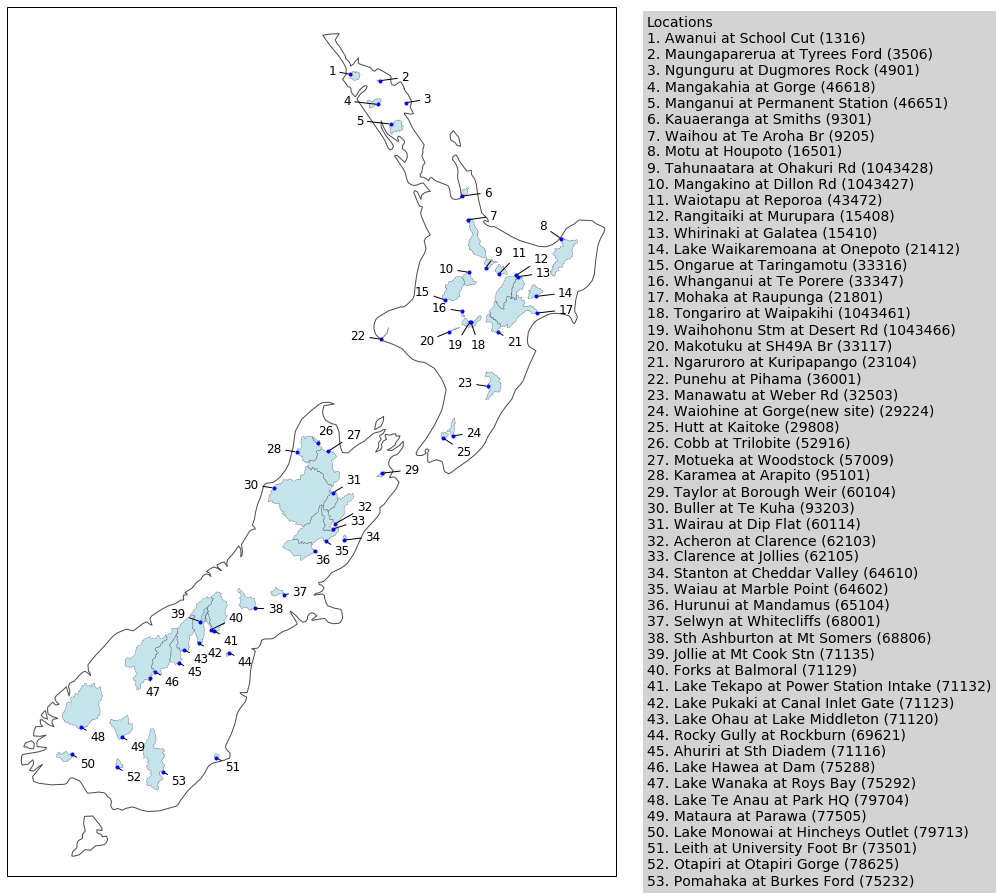

In [6]:
from matplotlib.image import imread

# Define the CartoPy CRS object.
crs = ccrs.Mercator()

# This can be converted into a `proj4` string/dict compatible with GeoPandas
crs_proj4 = crs.proj4_init
catchments_df_ae = catchments_df.to_crs(crs_proj4)
meta_df_ae = meta_df.to_crs(crs_proj4)

# Generate a CartoPy figure and add the countries to it
fig, ax = plt.subplots(figsize=(18,16),subplot_kw={'projection': crs})#,gridspec_kw={'width_ratios': [3, 1]})

catchments_df_ae.plot(ax=ax,color='lightblue',edgecolor='black',linewidth=0.2,alpha=0.7)
meta_df_ae.plot(ax=ax,color='blue',marker='.',)#fontsize=14)

ax.coastlines(resolution='50m', color='black', linewidth=1, alpha=0.7)

#ocean50 = cartopy.feature.NaturalEarthFeature('physical', 'ocean', \
#        scale='110m', edgecolor='none', facecolor=cartopy.feature.COLORS['water'])
#ax.add_feature(cartopy.feature.OCEAN)
#fname = os.path.join('path_to_natural_earth', 'NE1_50M_SR_W.tif')
#ax.imshow(imread(fname), origin='upper', transform=source_proj)

ax.set_xlim([1.85e7,1.99e7])
ax.set_ylim([-6000000,-4000000])

#ax.set_xticks(axs[0].get_xticks())
#ax.set_yticks(axs[0].get_yticks())

def find_ha(x):
    ha = 'left' if x in [13,18,24,27,32,34,41,42,45,46] else 'right'

    return ha


for i,site in enumerate(meta_df_ae.index):
    site_info = meta_df_ae.loc[site]
    number = site_info.number_label
    
    gauge_x = site_info.geometry.centroid.coords[0][0]
    gauge_y = site_info.geometry.centroid.coords[0][1]
    
    text_x = gauge_x + text_offsets[number][0]# if i%2 else gauge_x - 0.005e7
    text_y = gauge_y + text_offsets[number][1]
    
    ax.annotate(s=number,xy=(gauge_x,gauge_y),xytext=(text_x,text_y), size = 12,
                arrowprops=dict(arrowstyle="-",connectionstyle="arc3"),
                #bbox=dict(boxstyle="round", fc="lightgrey",alpha=0.3, ec="grey"),
               )


lst = "Locations"
for ind in meta_df_ae.index:
     lst += '\n' + str(meta_df_ae['number_label'][ind]) + '. ' + meta_df_ae['Name'][ind] + ' (' + str(meta_df_ae['number_copy'][ind]) + ')'
        
ax.annotate(lst,
            xy=(1.05, .99), xytext=(0.6, 0.1),
            arrowprops={'arrowstyle': '-'},
            xycoords=('axes fraction', 'axes fraction'),
            textcoords='offset points',
            size=14, ha='left', va='top',
            backgroundcolor='lightgrey',
            )

plt.savefig('Figure1.png',dpi=300,bbox_inches='tight')



In [50]:
plt.savefig('Figure1.png',dpi=300,bbox_inches='tight')